In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import os
import csv
from sklearn.metrics import accuracy_score

In [38]:
def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("A carregar os dados do arquivo salvo...")
        return np.load(save_path)
    
    print("A ler os dados do CSV...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])
# Carregar dados
data = np.load('all_data.npy')
print(data.shape) # ver dimensão (linhas, colunas)
print(data[:5]) # mostrar as primeiras 5 linhas

A carregar os dados do arquivo salvo...
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
(3930873, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.013

## 1.1

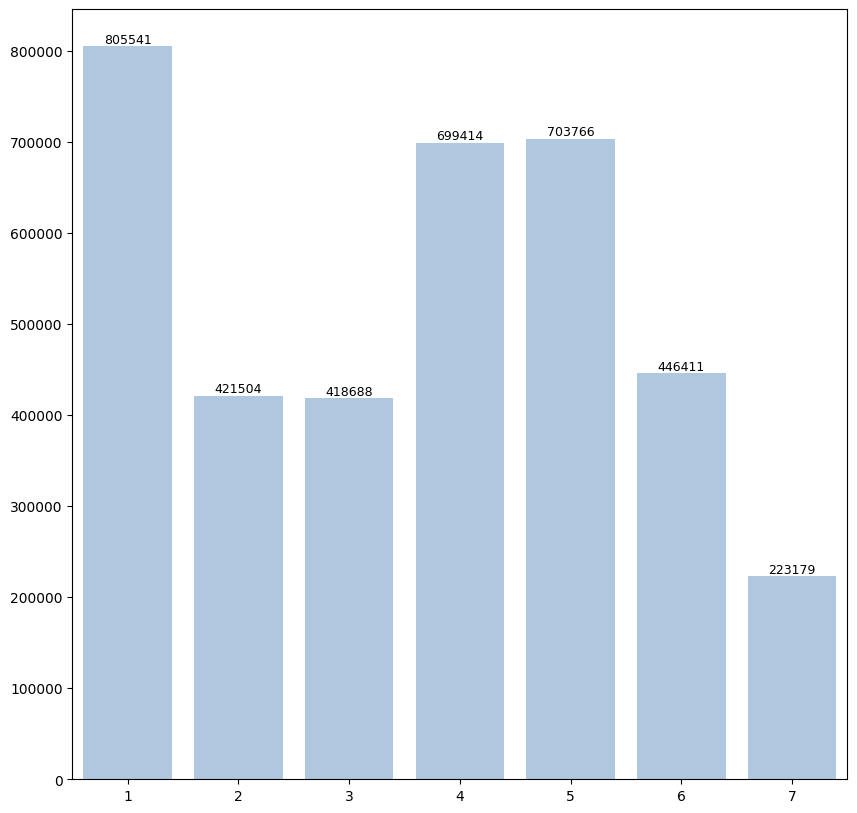

In [39]:
activity_labels = data[:, 12].astype(int)

# Filtrar apenas atividades 1 a 7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# Contar exemplos por atividade
atividades, contagens = np.unique(filtered_labels, return_counts=True)

# Plot com seaborn
plt.figure(figsize=(10,10))
grafico = sns.barplot(x=atividades, y=contagens, color='#A7C7E7')
grafico.bar_label(grafico.containers[0], fontsize=9)
plt.show()


## 1.2

In [40]:
def generate_smote_samples(X, y, activity_label, K, k_neighbors=5):

    current_count = np.sum(y == activity_label)
    target_count = current_count + K
    
    smote = SMOTE(
        sampling_strategy={activity_label: target_count},
        k_neighbors=k_neighbors
    )
    
    X_res, y_res = smote.fit_resample(X, y)
    dataset_augmented = np.hstack((X_res, y_res.reshape(-1,1)))
    return dataset_augmented


In [41]:
from sklearn.preprocessing import StandardScaler

ignore_cols = [0, 1, 11, 12]
feature_cols = [i for i in range(data.shape[1]) if i not in ignore_cols]


df_norm = data.copy().astype(float)

scaler = StandardScaler()
df_norm[:, feature_cols] = scaler.fit_transform(data[:, feature_cols])

X = df_norm[:, feature_cols]          # apenas sensores
y = data[:, 12].astype(int)           # coluna do label



dataset_augmented = generate_smote_samples(X, y, activity_label=4, K=5)
print("Shape dataset_augmented:", dataset_augmented.shape)

Shape dataset_augmented: (3930878, 10)


## 1.3

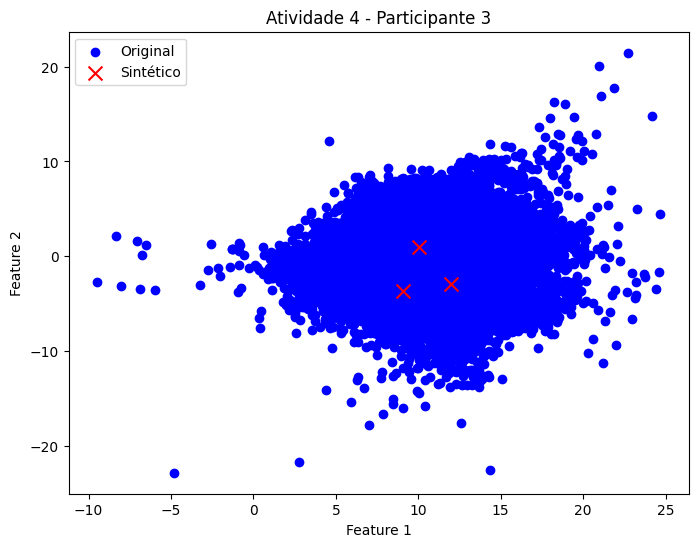

In [42]:
# Filtrar apenas participante 3
participant_id = 3
mask_participant = data[:, 0] == participant_id
data_participant = data[mask_participant]

# Separar features e label
feature_cols = list(range(2, 11))  # sensores
X_part = data_participant[:, feature_cols]
y_part = data_participant[:, 12].astype(int)

# Gerar 3 novas amostras para atividade 4
activity_label = 4
data_augmented = generate_smote_samples(X_part, y_part, activity_label=activity_label, K=3)

# --- 5. Separar exemplos ---
data_activity_original = data_participant[data_participant[:, 12] == activity_label]
num_original = data_activity_original.shape[0]

data_activity_augmented = data_augmented[data_augmented[:, -1] == activity_label]
original_samples = data_activity_augmented[:num_original]
synthetic_samples = data_activity_augmented[num_original:]

# Plotar o pedido
plt.figure(figsize=(8,6))
plt.scatter(original_samples[:, 1], original_samples[:, 2], color='blue', label='Original')
plt.scatter(synthetic_samples[:, 1], synthetic_samples[:, 2], color='red', label='Sintético', marker='x', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Atividade {activity_label} - Participante {participant_id}')
plt.legend()
plt.show()


-------------------------------------------------------------------------------

# Exercício 2 - Embedding Features

In [43]:
#codigo do stor do embedding 
import torch
import numpy as np


def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder


def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target


def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.5
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities



# load example file to test embedding
csv_file_path = '../FORTH_TRACE_DATASET/part13/part13dev1.csv'
 
csv_data = np.loadtxt(csv_file_path, delimiter=',')

original_segments, activities = acc_segmentation(csv_data)

resampled_segments = [resample_to_30hz_5s(segment, 51.5)[0] for segment in original_segments]

feature_encoder = load_model()


embeddings_list = []

# reshape segments to [n_segments, dimensions(xyz), time]
x_all = np.transpose( np.array(resampled_segments), (0, 2, 1) )
print(x_all.shape)

# iterate over the resampled segments and pass them 
#    through the model in batches to get the embeddings
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())

embeddings = np.concatenate(embeddings_list, axis=0)
print(embeddings.shape)

Using cache found in C:\Users\bmsam/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
(369, 3, 150)
(369, 512, 1)


In [44]:
import os

embeddings_list = []

base_path = '../FORTH_TRACE_DATASET'

for part_id in range(15):  # participantes de 0 a 14
    part_folder = os.path.join(base_path, f'part{part_id}')
    
    #todos os CSVs da pasta
    csv_files = sorted([f for f in os.listdir(part_folder) if f.endswith('.csv')])
    
    for csv_file in csv_files:
        csv_file_path = os.path.join(part_folder, csv_file)
        csv_data = np.loadtxt(csv_file_path, delimiter=',')
        
        # segmentar
        segments, activities = acc_segmentation(csv_data)
        
        # Filtrar apenas atividades 1 a 7
        segments_filtered = []
        participant_filtered = []
        activities_filtered= []
        for seg, act in zip(segments, activities):
            if 1 <= act <= 7:
                segments_filtered.append(seg)
                participant_filtered.append(part_id) 
                activities_filtered.append(act)

        if len(segments_filtered) == 0:
            continue
        
        # resample para 30Hz
        resampled_segments = [resample_to_30hz_5s(seg, 51.5)[0] for seg in segments_filtered]
        x_all = np.array([seg.T for seg in resampled_segments], dtype=np.float32)
        
        # extrair embeddings
        batch_size = 5
        with torch.no_grad():
            for i in range(0, x_all.shape[0], batch_size):
                xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
                eb = feature_encoder(xb)
                eb_np = eb.cpu().numpy()
                
                for j, seg_emb in enumerate(eb_np):
                    embeddings_list.append(
                        np.hstack([
                            participant_filtered[i+j],
                            activities_filtered[i+j],
                            seg_emb.flatten()
                        ])
                    )

# concatenar todos os participantes
embeddings_dataset = np.array(embeddings_list, dtype=np.float32)  
print(f"Shape final do embeddings_dataset (linhas x features+pid+atividade): {embeddings_dataset.shape}")

# exemplo
for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    if part_data.shape[0] == 0:
        continue
    print(f"Participante {pid} -> {part_data.shape[0]} segmentos")
    print("Exemplo de embedding (primeira linha, primeiras 10 dimensões):")
    print(part_data[0,:12]) 
    print("-"*30)

Shape final do embeddings_dataset (linhas x features+pid+atividade): (27699, 514)
Participante 0 -> 1846 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[0.         1.         0.         0.         0.         0.
 0.02792453 0.05044596 0.         0.04609096 0.         0.04253409]
------------------------------
Participante 1 -> 1844 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[1.         1.         0.         0.         0.         0.
 0.01917459 0.03401404 0.         0.04713296 0.         0.03870411]
------------------------------
Participante 2 -> 1847 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[2.         1.         0.         0.         0.         0.
 0.01478097 0.01832122 0.         0.0650632  0.         0.02626292]
------------------------------
Participante 3 -> 1849 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[3.0000000e+00 1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0

[participant_id, activity, embedding_1, embedding_2, ..., embedding_512]
como esta o dataset

---------------------------------

# Exercício 3 - Data splitting strategy

In [45]:
activity_col = 12  
activities = data[:, activity_col].astype(int)

mask = (activities >= 1) & (activities <= 7)
feature_dataset = data[mask]

print("Shape do FEATURE DATASET (atividades 1 a 7):", feature_dataset.shape)
print(feature_dataset[:5])

participants_data = {}
for part_id in range(15):
    part_rows = feature_dataset[feature_dataset[:, 0] == part_id]
    if len(part_rows) > 0:
        participants_data[part_id] = part_rows

for pid, pdata in participants_data.items():
    print(f"Participante {pid} -> {pdata.shape[0]} linhas")
    
    
# quais têm dados 
print("Participantes com dados:", list(participants_data.keys()))
print("Número de participantes com dados:", len(participants_data))


Shape do FEATURE DATASET (atividades 1 a 7): (3718503, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
Participante 0 -> 251314 linhas
Participante 1 -> 250546 linhas
Participante 2 -> 252210 linhas
Participante 3 -> 252082 linh

### 3.1

duvida: aqui é necessario que todas as atividades aparecam nos 3 conjuntos ou basta os participantes

In [46]:
from sklearn.model_selection import train_test_split
import numpy as np

# features
features_train_list = []
features_val_list = []
features_test_list = []

for id_p, pdata in participants_data.items():
    # 1º split
    train, temp = train_test_split(pdata, test_size=0.4, random_state=42, shuffle=True)
    
    # 2º split
    val, test = train_test_split(temp, test_size=0.5, random_state=42, shuffle=True)
    
    features_train_list.append(train)
    features_val_list.append(val)
    features_test_list.append(test)

# concatena todos os participantes
features_train = np.vstack(features_train_list)
features_val = np.vstack(features_val_list)
features_test = np.vstack(features_test_list)

print("FEATURES TRAIN:", features_train.shape)
print("FEATURES VAL:", features_val.shape)
print("FEATURES TEST:", features_test.shape)



print("-------")

# embeddings
emb_train_list = []
emb_val_list = []
emb_test_list = []

for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    
    train_x, temp_x = train_test_split(part_data, test_size=0.4, random_state=42, shuffle=True)
    val_x, test_x = train_test_split(temp_x, test_size=0.5, random_state=42, shuffle=True)
    
    emb_train_list.append(train_x)
    emb_val_list.append(val_x)
    emb_test_list.append(test_x)

# concatena todos os participantes
emb_train = np.concatenate(emb_train_list, axis=0)
emb_val = np.concatenate(emb_val_list, axis=0)
emb_test = np.concatenate(emb_test_list, axis=0)

print("EMBEDDINGS TRAIN:", emb_train.shape)
print("EMBEDDINGS VAL:", emb_val.shape)
print("EMBEDDINGS TEST:", emb_test.shape)


FEATURES TRAIN: (2231096, 13)
FEATURES VAL: (743700, 13)
FEATURES TEST: (743707, 13)
-------
EMBEDDINGS TRAIN: (16613, 514)
EMBEDDINGS VAL: (5539, 514)
EMBEDDINGS TEST: (5547, 514)


In [47]:
# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES TRAIN (primeiras 5 linhas)")
print(features_train[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS TRAIN (primeiras 5 linhas)")
print(emb_train[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES VALID (primeiras 5 linhas)")
print(features_val[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS VALID (primeiras 5 linhas)")
print(emb_val[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES TEST (primeiras 5 linhas)")
print(features_test[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS TEST (primeiras 5 linhas)")
print(emb_test[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)



FEATURES TRAIN (primeiras 5 linhas)
[[ 0.0000e+00  1.0000e+00 -1.4427e+00  7.5874e+00  2.8649e+00 -7.0031e+00
  -1.0849e+01 -1.0459e+01  3.5081e-01  6.2851e-01  8.8196e-01  9.0062e+05
   7.0000e+00]
 [ 0.0000e+00  1.0000e+00 -2.0345e+00  8.6151e+00  2.4416e+00 -5.5145e+01
   6.7410e-01 -8.5178e+01 -5.9476e-01  2.6908e-01  6.7261e-01  7.9236e+05
   4.0000e+00]
 [ 0.0000e+00  2.0000e+00  3.6687e+00  8.8409e+00  3.0143e+00  4.9095e+00
  -6.1770e+01 -1.0281e+02 -6.9772e-01  1.1012e+00  3.8158e-01  4.0077e+05
   4.0000e+00]
 [ 0.0000e+00  3.0000e+00 -1.5356e+00  1.0478e+01  2.3893e+00 -4.5181e-01
  -3.0509e+01 -6.8200e+00  2.2672e-01  4.4534e-01 -5.9000e-01  5.0683e+05
   5.0000e+00]
 [ 0.0000e+00  1.0000e+00 -4.6465e-01  7.5899e+00  5.7701e-01 -3.7749e+01
   8.0094e+01  2.8994e+01 -8.9919e-01  7.6305e-01 -2.4053e-01  6.6754e+05
   6.0000e+00]]
------------------------------
EMBEDDINGS TRAIN (primeiras 5 linhas)
[[0.0000000e+00 6.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.000

### 3.2

In [48]:
all_participants = np.arange(15)

#para ser aleatorio
np.random.seed(42) 
shuffled = np.random.permutation(all_participants)

train_participants = shuffled[:9]
val_participants   = shuffled[9:12]
test_participants  = shuffled[12:]

print("Treino (features & embeddings):", train_participants)
print("Validação (features & embeddings):", val_participants)
print("Teste (features & embeddings):", test_participants)


def filter_by_participants(dataset, participants):
    mask = np.isin(dataset[:, 0], participants)
    return dataset[mask]

# feature
features_train_subj = filter_by_participants(feature_dataset, train_participants)
features_val_subj   = filter_by_participants(feature_dataset, val_participants)
features_test_subj  = filter_by_participants(feature_dataset, test_participants)

print("\n------")
print("FEATURES TRAIN:", features_train_subj.shape)
print("FEATURES VAL  :", features_val_subj.shape)
print("FEATURES TEST :", features_test_subj.shape)



#embeddings
emb_train_subj = filter_by_participants(embeddings_dataset, train_participants)
emb_val_subj   = filter_by_participants(embeddings_dataset, val_participants)
emb_test_subj  = filter_by_participants(embeddings_dataset, test_participants)

print("\n------")
print("EMBEDDINGS TRAIN:", emb_train_subj.shape)
print("EMBEDDINGS VAL  :", emb_val_subj.shape)
print("EMBEDDINGS TEST :", emb_test_subj.shape)

Treino (features & embeddings): [ 9 11  0 13  5  8  2  1 14]
Validação (features & embeddings): [ 4  7 10]
Teste (features & embeddings): [12  3  6]

------
FEATURES TRAIN: (2232511, 13)
FEATURES VAL  : (729235, 13)
FEATURES TEST : (756757, 13)

------
EMBEDDINGS TRAIN: (16545, 514)
EMBEDDINGS VAL  : (5565, 514)
EMBEDDINGS TEST : (5589, 514)


In [49]:
# Features
print("FEATURES TRAIN (primeiras 5 linhas)")
print(features_train_subj[:5])
print("------------------------------")

print("FEATURES VAL (primeiras 5 linhas)")
print(features_val_subj[:5])
print("------------------------------")

print("FEATURES TEST (primeiras 5 linhas)")
print(features_test_subj[:5])
print("------------------------------")

# Embeddings
print("EMBEDDINGS TRAIN (primeiras 5 linhas)")
print(emb_train_subj[:5])
print("------------------------------")

print("EMBEDDINGS VAL (primeiras 5 linhas)")
print(emb_val_subj[:5])
print("------------------------------")

print("EMBEDDINGS TEST (primeiras 5 linhas)")
print(emb_test_subj[:5])
print("------------------------------")


FEATURES TRAIN (primeiras 5 linhas)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
------------------------------
FEATURES VAL (primeiras 5 linhas)
[[ 4.0000e+00  1.0000e+00 -2.2433e+00  9.4040e+00  1.5275e+00 -2.2024e+00
  -2.1982

VER MELHOR ISTO

*features_dataset*
as colunas representam : 
- coluna 0: ID do participante
- Coluna 1: device ID 
- coluna 2 a 11: valores das features
- coluna 12: timestamp
- coluna 13: label da atividade


*embeddings_dataset*
colunas representam:
- Coluna 0: ID do participante
- Coluna 1: device ID
- Colunas 2 a ultima: valores do embedding do segmento

### 3.3

No 3.1 cada participante contribui com dados de treino, validação e teste.
- Ou seja, cada participante está dividido em dados de treino, validação e teste. 
- Isto pode fazer com que o modelo aprenda padrões individuais daquele participante  

No 3.2 cada participante só está num dos conjuntos de dados: ou no de teste, ou de treino ou de validação.
- O modelo aqui não conhece padrões especificos de cada participante e por isso se calhar esta estratégia é mais realista



A melhor estratégia para ser aplicada aos novos participantes é então a 2º porque o modelo ainda não viu dados do mesmo individuo e consegue generalizar para novos participantes.

### 3.4

#### a)

para o exercicio 3.1

para o exercicio 3.2

#### b)

In [50]:
from sklearn.decomposition import PCA

def apply_pca(X_train, variance_threshold=0.90):
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)

    
    print(f"PCA - Número de componentes mantidos: {pca.n_components_}")
    return X_train_pca


In [51]:
print ("-----para o 3.1")
# Features
feat_train_pca= apply_pca(features_train)
# Embeddings
emb_train_pca= apply_pca(emb_train)

# Mostrar shapes PCA
print("FEATURES TRAIN PCA:", feat_train_pca.shape)
print("EMBEDDINGS TRAIN PCA:", emb_train_pca.shape)


print("-------para o 3.2")

feat_train_subj_pca= apply_pca( features_train_subj)
# Embeddings
emb_train_subj_pca= apply_pca(emb_train_subj)

# Mostrar shapes PCA
print("FEATURES TRAIN PCA:", feat_train_subj_pca.shape)
print("EMBEDDINGS TRAIN PCA:", emb_train_subj_pca.shape)


-----para o 3.1
PCA - Número de componentes mantidos: 1
PCA - Número de componentes mantidos: 1
FEATURES TRAIN PCA: (2231096, 1)
EMBEDDINGS TRAIN PCA: (16613, 1)
-------para o 3.2
PCA - Número de componentes mantidos: 1
PCA - Número de componentes mantidos: 1
FEATURES TRAIN PCA: (2232511, 1)
EMBEDDINGS TRAIN PCA: (16545, 1)


#### c)

In [52]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

def reliefF_select_from_numpy(dataset, n_neighbors=10, n_features_select=15, 
                              random_state=42, sample_size=5000):
    """
    Aplica ReliefF num dataset numpy e retorna as n_features_select mais importantes.
    
    Parâmetros:
    - dataset: numpy array com coluna 0 = individuo, última coluna = label
    - n_neighbors: número de vizinhos para ReliefF
    - n_features_select: número de features a retornar
    - random_state: para reprodutibilidade
    - sample_size: número de exemplos a usar para calcular ReliefF (para não explodir memória)
    
    Retorna:
    - reduced_df: DataFrame com top features + individuo + label
    - selected_columns: lista dos nomes das features selecionadas
    - weights: vetor de pesos das features originais
    """
    np.random.seed(random_state)
    
    n_samples, n_cols = dataset.shape
    feature_cols = np.arange(1, n_cols-1)  # todas as features exceto individuo e label
    X = dataset[:, feature_cols]
    y = dataset[:, -1]
    
    # --- amostragem para grandes datasets ---
    if n_samples > sample_size:
        idx = np.random.choice(n_samples, sample_size, replace=False)
        X_sample = X[idx]
        y_sample = y[idx]
    else:
        X_sample = X
        y_sample = y
    
    n_samples_sample, n_features = X_sample.shape
    weights = np.zeros(n_features)
    
    # ReliefF: percorre exemplos aleatórios da amostra
    for _ in range(n_samples_sample):
        i = np.random.randint(0, n_samples_sample)
        xi, yi = X_sample[i], y_sample[i]
        
        same_class = np.where(y_sample == yi)[0]
        diff_class = np.where(y_sample != yi)[0]
        
        # Calcula distâncias localmente
        same_dists = np.sum((X_sample[same_class] - xi)**2, axis=1)
        diff_dists = np.sum((X_sample[diff_class] - xi)**2, axis=1)
        
        near_hits_idx = same_class[np.argsort(same_dists)[1:n_neighbors+1]]
        near_misses_idx = diff_class[np.argsort(diff_dists)[:n_neighbors]]
        
        near_hits = X_sample[near_hits_idx]
        near_misses = X_sample[near_misses_idx]
        
        for j in range(n_features):
            hit_term = np.sum((xi[j] - near_hits[:, j])**2) / n_neighbors
            miss_term = np.sum((xi[j] - near_misses[:, j])**2) / n_neighbors
            weights[j] += miss_term - hit_term
    
    # Normaliza
    weights /= n_samples_sample
    
    # Seleciona top features
    selected_indices = np.argsort(weights)[::-1][:n_features_select]
    selected_columns = [f'feature_{i}' for i in feature_cols[selected_indices]]
    
    # Cria DataFrame reduzido (aplica indices no dataset completo)
    reduced_df = pd.DataFrame(X[:, selected_indices], columns=selected_columns)
    reduced_df['individuo'] = dataset[:, 0]
    reduced_df['label'] = y
    
    return reduced_df, selected_columns, weights


3.1

In [53]:
# --- Features ---
reduced_features_train, top_features, feature_weights = reliefF_select_from_numpy(
    features_train, n_features_select=15, sample_size=5000
)
print("Top 15 features train shape:", reduced_features_train.shape)



# --- Embeddings ---
reduced_emb_train, top_emb_features, emb_weights = reliefF_select_from_numpy(
    emb_train, n_features_select=15, sample_size=5000
)
print("Top 15 embeddings train shape:", reduced_emb_train.shape)

Top 15 features train shape: (2231096, 13)
Top 15 embeddings train shape: (16613, 17)


3.2

In [54]:
# --- Features ---
reduced_features_train_subj, top_features_subj, feature_weights_subj = reliefF_select_from_numpy(
    features_train_subj, n_features_select=15, sample_size=5000
)
print("Top 15 features train shape:", reduced_features_train_subj.shape)

# --- Embeddings ---
reduced_emb_train_subj, top_emb_features_subj, emb_weights_subj = reliefF_select_from_numpy(
    emb_train_subj, n_features_select=15, sample_size=5000
)
print("Top 15 embeddings train shape:", reduced_emb_train_subj.shape)

Top 15 features train shape: (2232511, 13)
Top 15 embeddings train shape: (16545, 17)


-------------------------------------------------------------------------------

## 4 - Model learning
We will now train a model to automatically classify the activity of each segment. We will use k-Nearest Neighbors.

### 4.1
Implement a k-Nearest Neighbors classifier (we expect you to implement your own version, but then you can use the sci-kit learn version if you need better performance. See information in [sklearn_KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

In [65]:
# Each line is a segment (window of 5 seconds with 50% overlap)
# Inside each windows the first index is a window, second is a column (variable) and each window contains x lines from the original dataset.

class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y têm de ser igual.")
        
    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))
    
    def predict(self, X):
        X_test = np.array(X)
        predictions = []

        for test_point in X_test:
            # Calcukar distâncias para todos os pontos de treino
            distances = np.linalg.norm(self.X_train - test_point, axis=1)
            # Obter os índices dos k vizinhos mais próximos
            k_indices = np.argsort(distances)[:self.k]
            # Obter as labels dos k vizinhos
            k_nearest_labels = self.y_train[k_indices]
            # Aprovar por maioria
            most_common = np.bincount(k_nearest_labels.astype(int)).argmax()
            predictions.append(most_common)

        return np.array(predictions)


import torch

class KNNClassifierGPU:
    def __init__(self, k=5, device='cuda'):
        self.k = k
        self.device = device if torch.cuda.is_available() else 'cpu'
        
    def fit(self, X, y):
        self.X_train = torch.tensor(X, dtype=torch.float32, device=self.device)
        self.y_train = torch.tensor(y, dtype=torch.int64, device=self.device)
        
    def predict(self, X, batch_size=1000):
        X_test = torch.tensor(X, dtype=torch.float32, device=self.device)
        predictions = []
        
        # Processar em batches para não estourar memória da GPU
        for i in range(0, len(X_test), batch_size):
            batch = X_test[i:i+batch_size]
            # Calcular distâncias (broadcasting)
            dists = torch.cdist(batch, self.X_train)
            # K vizinhos mais próximos
            _, indices = torch.topk(dists, self.k, largest=False)
            k_labels = self.y_train[indices]
            # Votação por maioria
            preds = torch.mode(k_labels, dim=1).values
            predictions.append(preds)
            
        return torch.cat(predictions).cpu().numpy()

# Usar
#gpu_knn = KNNClassifierGPU(k=5)
#gpu_knn.fit(X_train, y_train)
#y_pred = gpu_knn.predict(X_test)

In [ ]:
# ============== ESTRATÉGIA 3.1 - WITHIN SUBJECT ==============

# --- FEATURES (all) ---
X_train_feat = features_train[:, 2:11]  # features são colunas 2-10
y_train_feat = features_train[:, 12]     # label é coluna 12

X_val_feat = features_val[:, 2:11]
y_val_feat = features_val[:, 12]

X_test_feat = features_test[:, 2:11]
y_test_feat = features_test[:, 12]

# --- EMBEDDINGS (all) ---
X_train_emb = emb_train[:, 2:]    # embeddings são colunas 2 em diante
y_train_emb = emb_train[:, 1]      # label é coluna 1

X_val_emb = emb_val[:, 2:]
y_val_emb = emb_val[:, 1]

X_test_emb = emb_test[:, 2:]
y_test_emb = emb_test[:, 1]


# ============== ESTRATÉGIA 3.2 - BETWEEN SUBJECTS ==============

# --- FEATURES (all) ---
X_train_feat_subj = features_train_subj[:, 2:11]
y_train_feat_subj = features_train_subj[:, 12]

X_val_feat_subj = features_val_subj[:, 2:11]
y_val_feat_subj = features_val_subj[:, 12]

X_test_feat_subj = features_test_subj[:, 2:11]
y_test_feat_subj = features_test_subj[:, 12]

# --- EMBEDDINGS (all) ---
X_train_emb_subj = emb_train_subj[:, 2:]
y_train_emb_subj = emb_train_subj[:, 1]

X_val_emb_subj = emb_val_subj[:, 2:]
y_val_emb_subj = emb_val_subj[:, 1]

X_test_emb_subj = emb_test_subj[:, 2:]
y_test_emb_subj = emb_test_subj[:, 1]

# Verificar shapes
print("=== Estratégia 3.1 ===")
print(f"Features: X_train={X_train_feat.shape}, y_train={y_train_feat.shape}")
print(f"Embeddings: X_train={X_train_emb.shape}, y_train={y_train_emb.shape}")

print("\n=== Estratégia 3.2 ===")
print(f"Features: X_train={X_train_feat_subj.shape}, y_train={y_train_feat_subj.shape}")
print(f"Embeddings: X_train={X_train_emb_subj.shape}, y_train={y_train_emb_subj.shape}")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_model(y_true, y_pred, class_names=None, plot_cm=True):
    """
    Avalia um modelo de classificação e retorna métricas completas.
    
    Parameters:
    -----------
    y_true : array-like
        Labels verdadeiros
    y_pred : array-like
        Labels preditos
    class_names : list, optional
        Nomes das classes (atividades)
    plot_cm : bool
        Se True, plota a matriz de confusão
    
    Returns:
    --------
    dict com todas as métricas
    """
    # Nomes das atividades (1-7)
    if class_names is None:
        class_names = ['Walking', 'Walking Up', 'Walking Down', 
                       'Sitting', 'Standing', 'Lying', 'Running']
    
    # Classification report completo
    report = classification_report(
        y_true, y_pred, 
        target_names=class_names,
        output_dict=True,  # Retorna como dicionário para fácil acesso
        zero_division=0
    )
    
    # Imprimir report formatado
    print("=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    # Métricas globais
    print("=" * 60)
    print("MÉTRICAS GLOBAIS")
    print("=" * 60)
    print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1-Score:     {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Weighted F1-Score:  {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Macro Precision:    {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Macro Recall:       {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    
    if plot_cm:
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()
    
    # Retornar dicionário com todas as métricas
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'confusion_matrix': cm,
        'report_dict': report
    }
    
    return metrics

# Testar com embeddings primeiro (dataset menor ~27k linhas)
print("=== Strategy 3.1 - Embeddings (All) ===")

gpu_knn = KNNClassifierGPU(k=5)
gpu_knn.fit(X_train_emb, y_train_emb)
y_pred = gpu_knn.predict(X_test_emb)
metrics = evaluate_model(y_test_emb, y_pred)

NameError: name 'features_train' is not defined

### 4.2
Create a function that receives two lists of values: the true labels and predicted labels, and returns a set of classification metrics: confusion matrix, accuracy, f1 score, precision, recall, etc.

In [ ]:
#Teste

-------------------------------------------------------------------------------

## 5 - Model evaluation
For each splitting strategy (2) applied for the 3 versions (all feats, PCA feats, ReliefF feats) of the 2 datasets (features, embeddings), train the classifier and evaluate its results:

### 5.1 Hyperparameter tuning
Select the best value of k using only the train and validation data. Then, with the best k, retrain with the dataset (train + validation) and evaluate on the test set.

### 5.2 Report and analyse results
Check the confusion matrices and observe which activities are harder to classify. Which dataset worked best (features vs embeddings)? Did feature selection improve the performance? Etc.

### 5.3 Perform hypothesis testing to compare the models
Is the best model statistically significantly better than the others? Justify the choice of the statistical tests you use. (NOTE: repeat the train-validation-test split several times to obtain the performance distributions of each model)

-------------------------------------------------------------------------------

## 6 - Deployment
Pick the best model from question 5 and make a function that receives a numpy array of shape 256 lines and 9 columns (acc x y z, gyr x y z, mag x y z) and performs all the necessary steps to return a classification from the model (normalization, feature extraction / embeddings generation, [PCA, Feature Selection], classification).

-------------------------------------------------------------------------------

## 7 - Go further
Discuss what can be done more to improve your classification system.

### 7.1 (BONUS) Implement and evaluate some of those ideas!